# Food Delivery Business Performance – Data Visualization Portfolio

## Objective

This project analyzes the Food Delivery Business Performance dataset using Python, Pandas, Matplotlib, and Seaborn. Various visualization techniques are used to identify trends and relationships in orders, revenue, marketing spend, delivery time, customer ratings, cities, cuisines, weather conditions, and order channels.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Day14_Food_Delivery_Visualization_Dataset.csv')

# Display first 5 rows
df.head()

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [3]:
# Check dataset information
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Shape of dataset: (360, 16)

Column names:
['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine', 'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    object 
 1   Date                     360 non-null    object 
 2   Month                    360 non-null    object 
 3   Day                      360 non-null    object 
 4   City                     360 non-null    object 
 5   Cuisine                  360 non-null    object 
 6   Order_Channel            360 non-null    object 
 7   Weather                  360 non-null    object 
 8   Orders                   360 non-null    int64  


In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Order_Batch_ID             0
Date                       0
Month                      0
Day                        0
City                       0
Cuisine                    0
Order_Channel              0
Weather                    0
Orders                     0
Average_Order_Value        0
Revenue                    0
Marketing_Spend            0
Discounts                  0
Avg_Delivery_Minutes       0
Customer_Rating            0
Repeat_Customer_Percent    0
dtype: int64


In [5]:
df.describe()

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,147.647222,409.151083,60591.114778,27161.430028,5753.397000,32.577500,4.452861,41.600000
std,33.387161,70.249186,17387.926132,6970.558278,2647.410844,5.281562,0.209699,5.336472
min,58.000000,243.760000,20618.530000,11336.640000,1219.310000,20.600000,3.810000,24.800000
25%,123.750000,353.840000,48400.832500,21822.500000,3566.615000,28.675000,4.310000,37.900000
50%,147.000000,412.410000,58779.190000,25874.140000,5226.870000,32.000000,4.470000,41.900000
75%,169.000000,464.945000,71740.142500,32387.137500,7610.367500,35.950000,4.610000,45.225000
max,235.000000,575.940000,121381.980000,45000.000000,15000.000000,50.100000,4.940000,54.000000


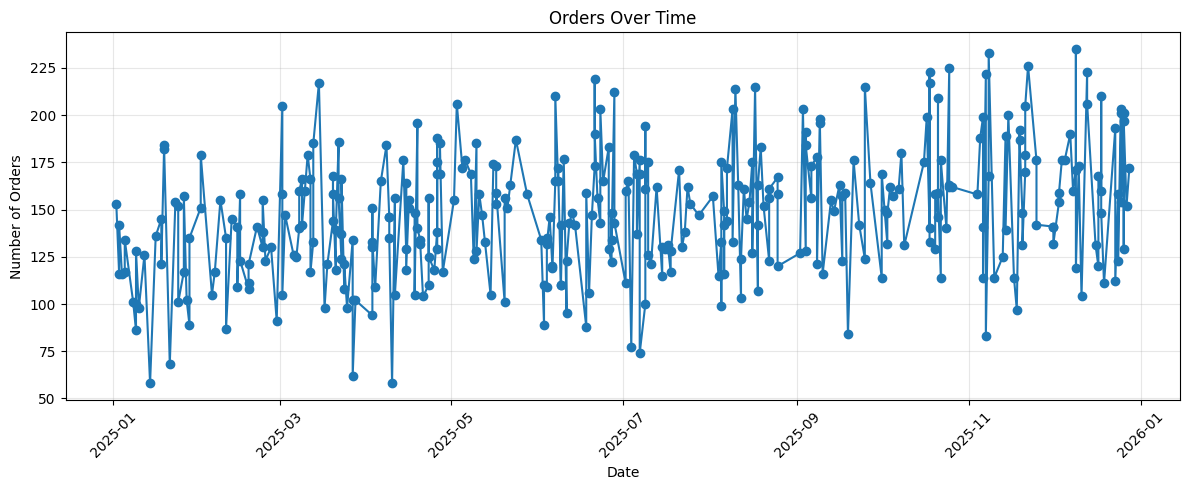

In [6]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df_time = df.sort_values('Date')

# Line plot for Orders
plt.figure(figsize=(12, 5))
plt.plot(df_time['Date'], df_time['Orders'], marker='o')

plt.title('Orders Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation
The line plot shows how the number of food delivery orders changes over time. The number of orders fluctuates across different dates, indicating variations in customer demand. Peaks represent periods of higher order activity, while lower points indicate comparatively reduced demand.

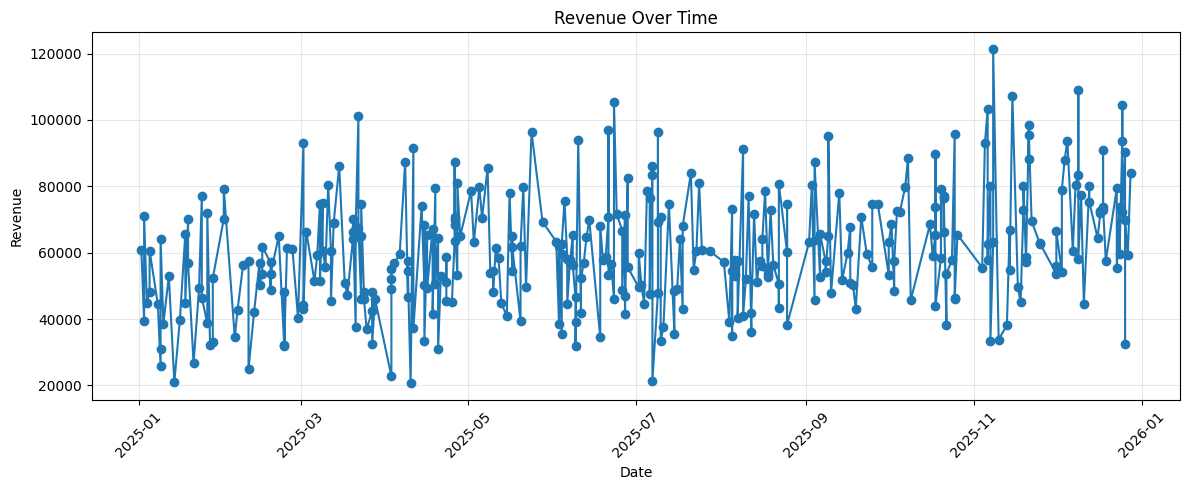

In [7]:
# Line plot for Revenue
plt.figure(figsize=(12, 5))
plt.plot(df_time['Date'], df_time['Revenue'], marker='o')

plt.title('Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation
The revenue line shows how total revenue varies over time. Revenue generally changes with fluctuations in order activity and average order value. Higher revenue points indicate stronger business performance during those periods.

#Bar Charts


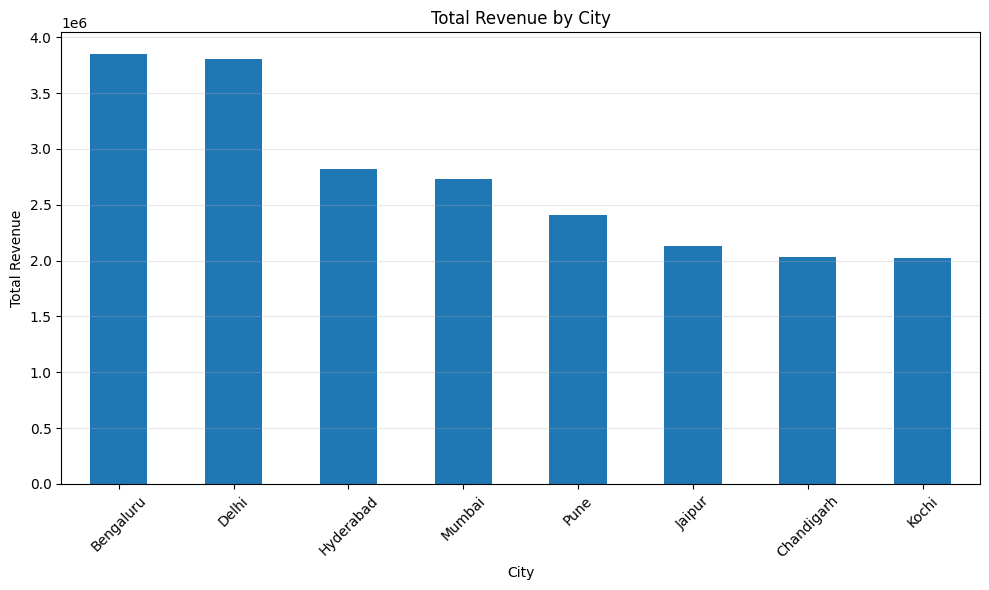

In [8]:
# Calculate total revenue by city
city_revenue = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(10, 6))
city_revenue.plot(kind='bar')

plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation
The bar chart compares the total revenue generated by different cities. The city with the tallest bar contributes the highest total revenue, while the city with the shortest bar contributes the lowest. This helps identify the strongest and weakest performing cities in terms of revenue.

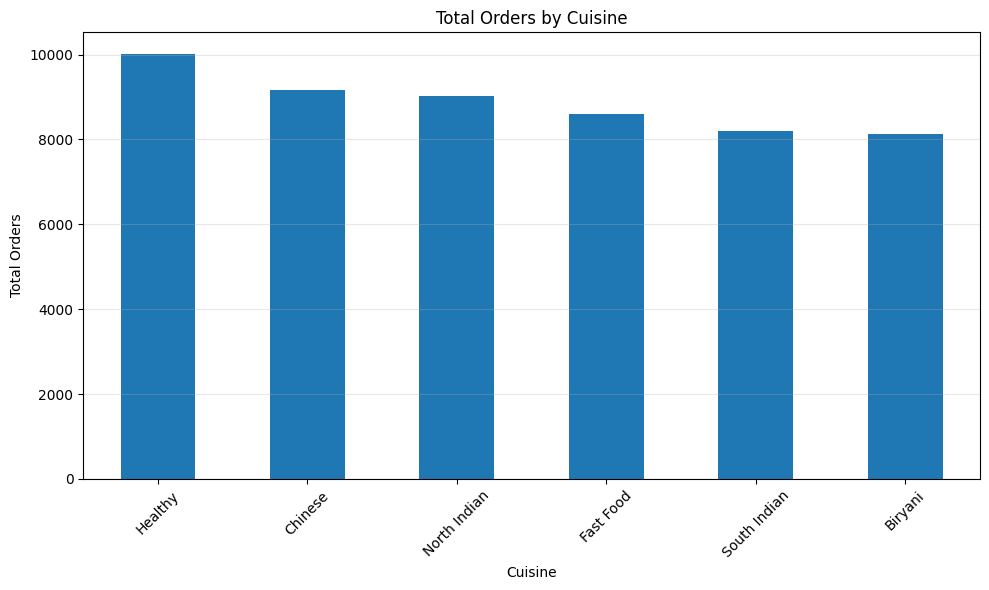

In [9]:
# Calculate total orders by cuisine
cuisine_orders = df.groupby('Cuisine')['Orders'].sum().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(10, 6))
cuisine_orders.plot(kind='bar')

plt.title('Total Orders by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation
The bar chart shows the total number of orders for each cuisine. Some cuisines receive considerably more orders than others, indicating differences in customer preferences. The most popular cuisine has the highest total order volume and may represent an important category for the business.

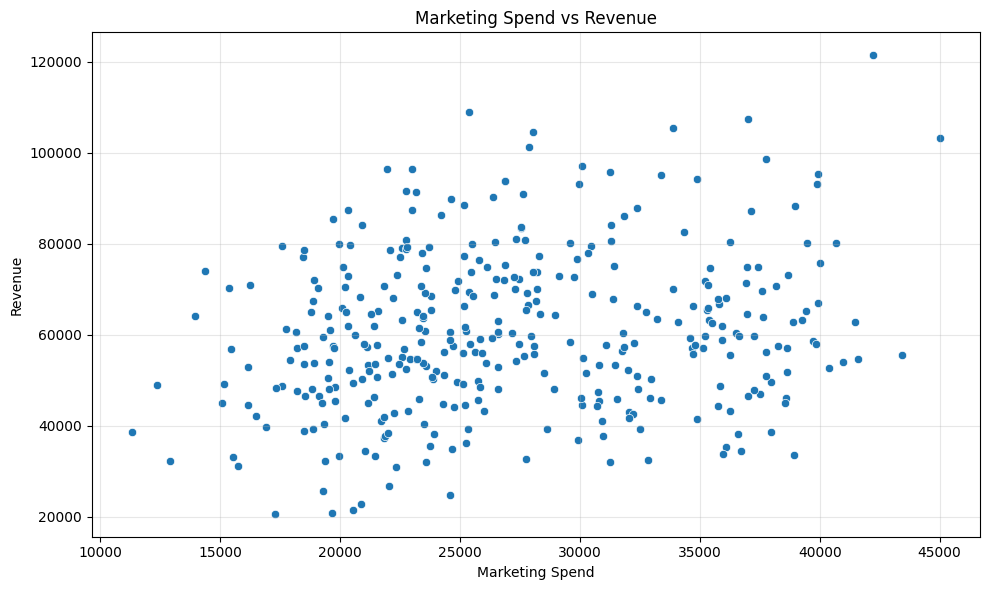

In [10]:
# Scatter plot: Marketing Spend vs Revenue
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Marketing_Spend',
    y='Revenue'
)

plt.title('Marketing Spend vs Revenue')
plt.xlabel('Marketing Spend')
plt.ylabel('Revenue')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

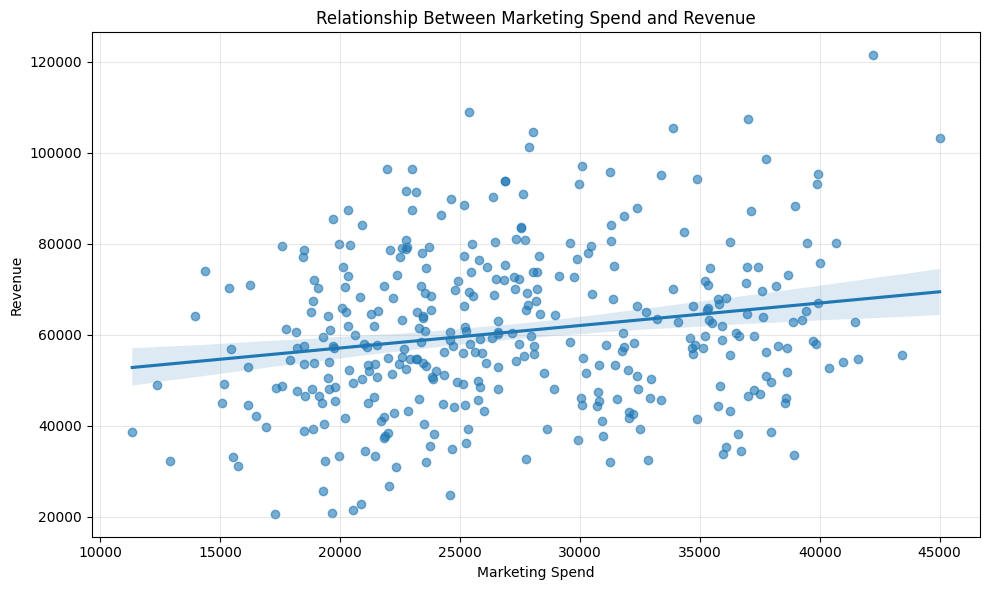

In [11]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Marketing_Spend',
    y='Revenue',
    scatter_kws={'alpha': 0.6}
)

plt.title('Relationship Between Marketing Spend and Revenue')
plt.xlabel('Marketing Spend')
plt.ylabel('Revenue')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The correlation between Marketing Spend and Revenue is approximately 0.198, indicating a weak positive relationship. This suggests that higher marketing spending is associated with slightly higher revenue, but the relationship is not strong. Therefore, other factors besides marketing expenditure are likely to have a greater influence on revenue.

In [12]:
correlation = df['Marketing_Spend'].corr(df['Revenue'])
print("Correlation between Marketing Spend and Revenue:", correlation)

Correlation between Marketing Spend and Revenue: 0.19812719039135182


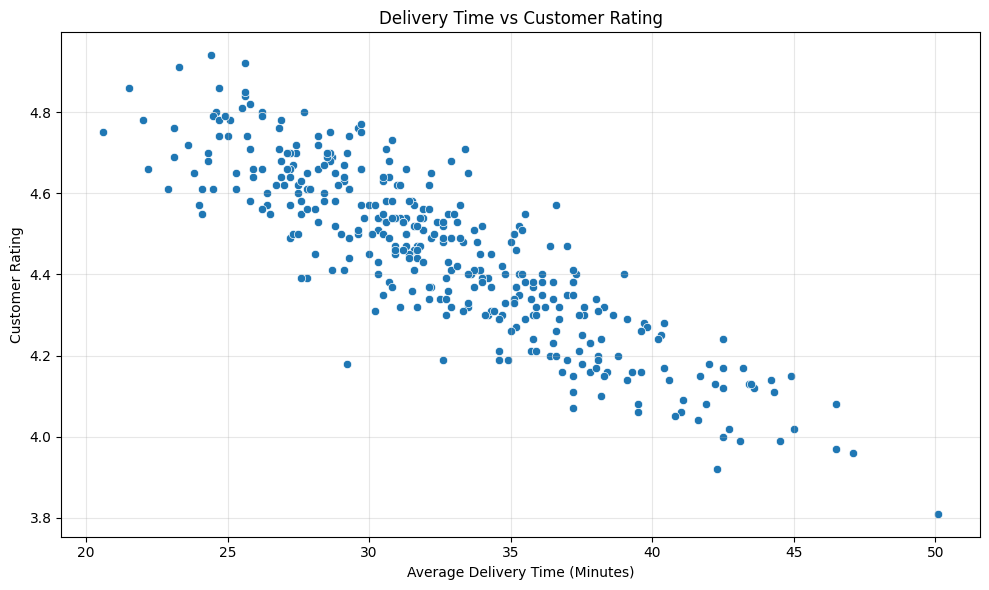

In [13]:
# Scatter plot: Delivery Time vs Customer Rating
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Avg_Delivery_Minutes',
    y='Customer_Rating'
)

plt.title('Delivery Time vs Customer Rating')
plt.xlabel('Average Delivery Time (Minutes)')
plt.ylabel('Customer Rating')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

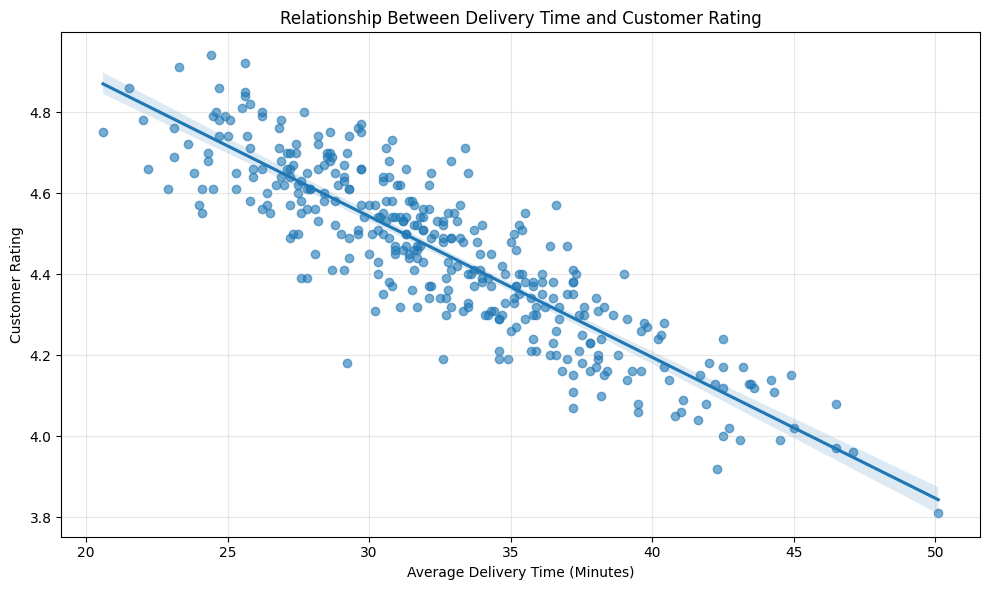

In [14]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Avg_Delivery_Minutes',
    y='Customer_Rating',
    scatter_kws={'alpha': 0.6}
)

plt.title('Relationship Between Delivery Time and Customer Rating')
plt.xlabel('Average Delivery Time (Minutes)')
plt.ylabel('Customer Rating')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The correlation between Average Delivery Time and Customer Rating is approximately -0.876, indicating a strong negative relationship. This means that longer delivery times are strongly associated with lower customer ratings. Therefore, improving delivery speed may be important for maintaining higher customer satisfaction.

In [15]:
correlation = df['Avg_Delivery_Minutes'].corr(df['Customer_Rating'])
print("Correlation between Delivery Time and Customer Rating:", correlation)

Correlation between Delivery Time and Customer Rating: -0.8758810555011177


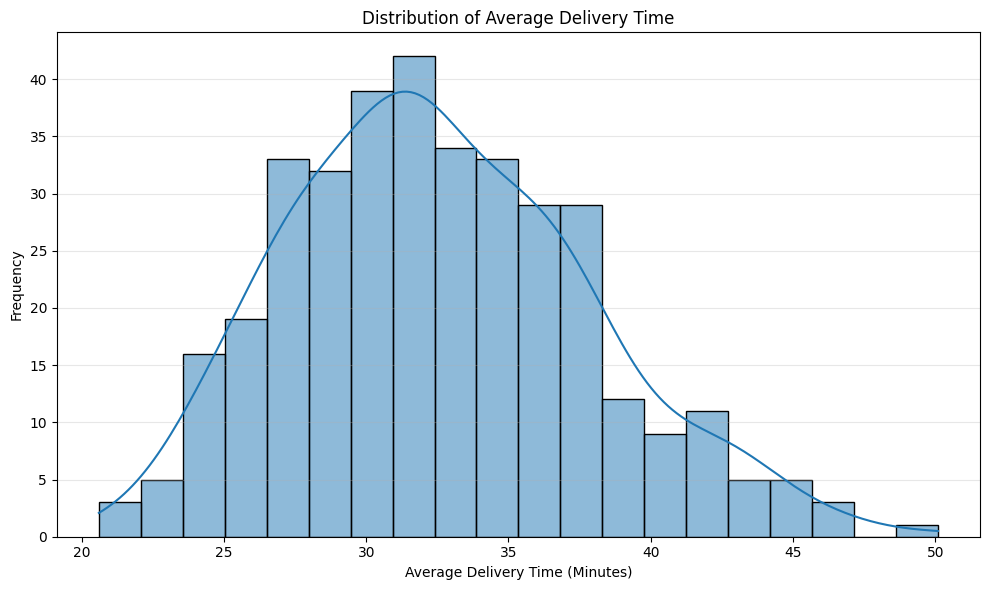

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Avg_Delivery_Minutes',
    bins=20,
    kde=True
)

plt.title('Distribution of Average Delivery Time')
plt.xlabel('Average Delivery Time (Minutes)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The histogram shows the distribution of average delivery times in the dataset. Most observations are concentrated within a particular range of delivery times, while relatively fewer observations occur at the extreme values. The KDE curve helps visualize the overall shape of the distribution.

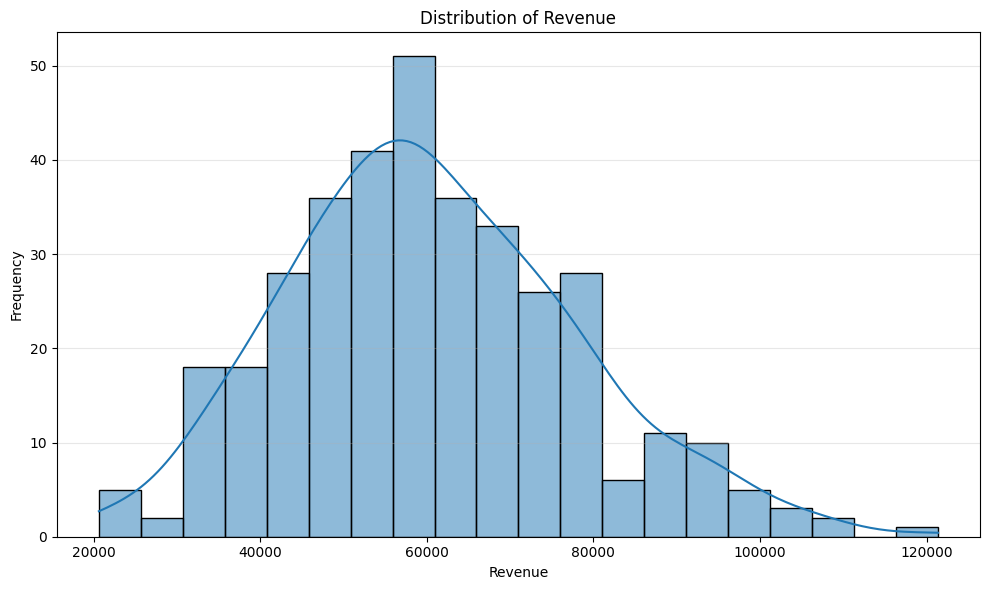

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Revenue',
    bins=20,
    kde=True
)

plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The histogram shows how revenue values are distributed across the dataset. It helps identify the typical revenue range and whether the data contains unusually high or low revenue values. The distribution provides an overview of the variation in business performance across different observations.

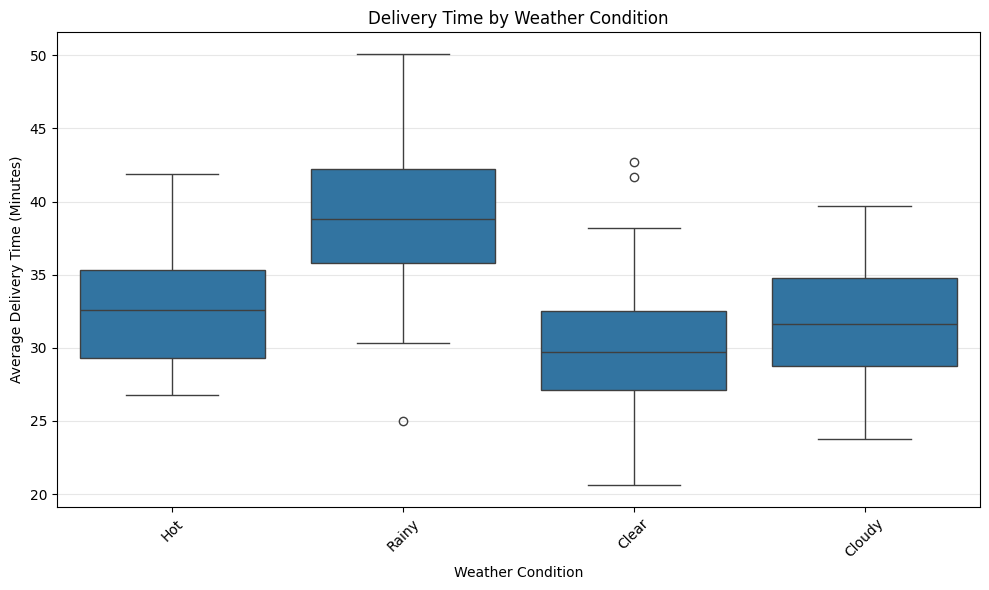

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Weather',
    y='Avg_Delivery_Minutes'
)

plt.title('Delivery Time by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Delivery Time (Minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The box plot compares delivery times across different weather conditions. It shows the median delivery time, spread of the data, and potential outliers for each weather category. Weather conditions with higher median delivery times may indicate that unfavorable weather makes food delivery more difficult or slower.

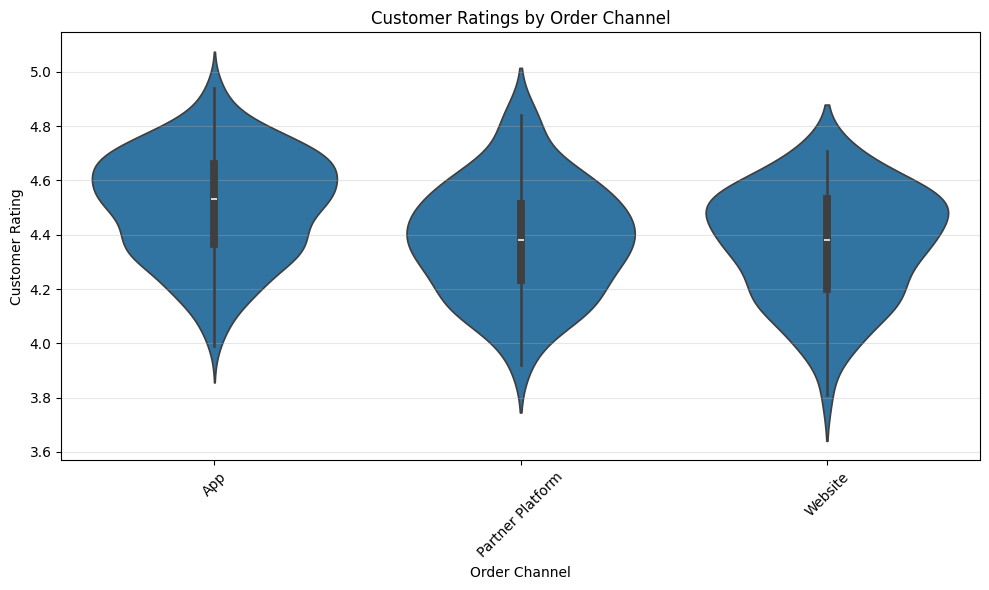

In [20]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='Order_Channel',
    y='Customer_Rating'
)

plt.title('Customer Ratings by Order Channel')
plt.xlabel('Order Channel')
plt.ylabel('Customer Rating')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The violin plot shows the distribution of customer ratings across different order channels. Wider sections represent areas where more observations are concentrated. Comparing the distributions helps identify which order channels tend to receive higher or lower customer ratings and how consistent the ratings are within each channel.

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='Weather'
)

plt.title('Number of Records by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The count plot shows how frequently each weather condition occurs in the dataset. This provides context for comparing business performance under different weather conditions. Weather categories with more observations have a larger representation in the dataset.

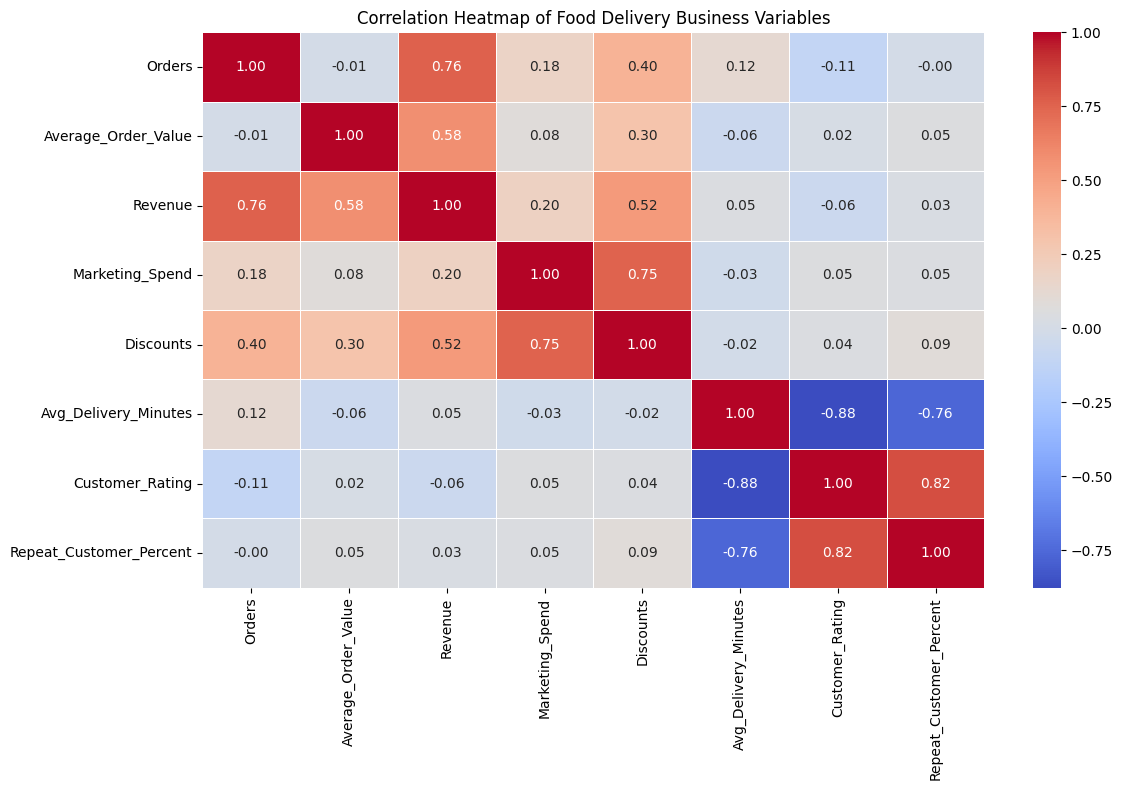

In [19]:
# Select numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Create heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Food Delivery Business Variables')
plt.tight_layout()
plt.show()

### Interpretation

The correlation heatmap displays the relationships between the numerical variables in the dataset. Positive correlations indicate that two variables tend to increase together, while negative correlations indicate that one variable tends to decrease as the other increases. The heatmap helps identify strong relationships that may be useful for understanding food delivery business performance.

## Overall Findings

The visualization analysis of the Food Delivery Business Performance dataset revealed several important patterns:

1. **Orders and revenue vary over time**, showing fluctuations in business activity across different dates.

2. **City performance differs**, with some cities generating substantially higher total revenue than others.

3. **Cuisine preferences vary**, with certain cuisines receiving more orders and therefore representing stronger customer demand.

4. **Marketing spend has a weak positive relationship with revenue**, with a correlation of approximately **0.198**. This suggests that marketing expenditure alone does not strongly explain revenue differences.

5. **Delivery time has a strong negative relationship with customer ratings**, with a correlation of approximately **-0.876**. This indicates that longer delivery times are strongly associated with lower customer satisfaction.

6. **Delivery times vary across weather conditions**, suggesting that weather can influence delivery operations.

7. **Customer ratings differ across order channels**, showing that the distribution of customer satisfaction is not necessarily the same for every channel.

8. The **correlation heatmap** provides an overall view of the relationships between the numerical variables and helps identify the variables most strongly associated with business performance.

### Conclusion

Overall, the analysis shows that **delivery efficiency and customer satisfaction are closely related**, while marketing spend has a comparatively weak relationship with revenue. Differences between cities, cuisines, weather conditions, and order channels also provide useful insights that can help a food delivery business improve its operations and customer experience.